In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Load Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Print dataset shapes
print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


In [3]:
# Fashion MNIST labels
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

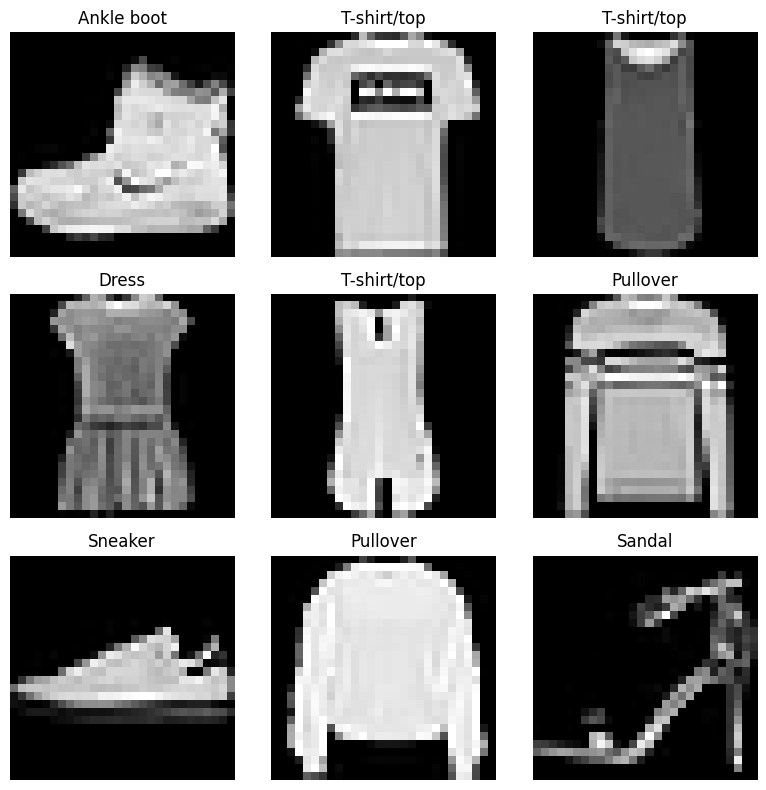

In [5]:
# Display first 9 images
plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
# Reshape images for CNN
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

print("Reshaped Training Shape:", x_train.shape)
print("Reshaped Testing Shape:", x_test.shape)

Reshaped Training Shape: (60000, 28, 28, 1)
Reshaped Testing Shape: (10000, 28, 28, 1)


In [7]:
# Normalize pixel values
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [8]:
# Convert labels into categorical format
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

y_train Shape: (60000, 10)
y_test Shape: (10000, 10)


In [9]:
# Create CNN model
model = Sequential([

    # First Convolution Layer
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    # Second Convolution Layer
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Flatten Layer
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Output Layer
    Dense(10, activation='softmax')
])

# Print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
# Train the CNN model
history = model.fit(x_train,y_train,epochs=10,batch_size=128,validation_split=0.1,verbose=2
)

Epoch 1/10
422/422 - 40s - 96ms/step - accuracy: 0.9307 - loss: 0.1846 - val_accuracy: 0.9152 - val_loss: 0.2407
Epoch 2/10
422/422 - 37s - 87ms/step - accuracy: 0.9320 - loss: 0.1796 - val_accuracy: 0.9183 - val_loss: 0.2325
Epoch 3/10
422/422 - 41s - 97ms/step - accuracy: 0.9349 - loss: 0.1719 - val_accuracy: 0.9235 - val_loss: 0.2273
Epoch 4/10
422/422 - 37s - 88ms/step - accuracy: 0.9373 - loss: 0.1653 - val_accuracy: 0.9183 - val_loss: 0.2323
Epoch 5/10
422/422 - 41s - 97ms/step - accuracy: 0.9380 - loss: 0.1610 - val_accuracy: 0.9170 - val_loss: 0.2473
Epoch 6/10
422/422 - 40s - 94ms/step - accuracy: 0.9411 - loss: 0.1551 - val_accuracy: 0.9220 - val_loss: 0.2354
Epoch 7/10
422/422 - 37s - 87ms/step - accuracy: 0.9437 - loss: 0.1493 - val_accuracy: 0.9230 - val_loss: 0.2394
Epoch 8/10
422/422 - 40s - 96ms/step - accuracy: 0.9463 - loss: 0.1438 - val_accuracy: 0.9218 - val_loss: 0.2466
Epoch 9/10
422/422 - 41s - 97ms/step - accuracy: 0.9463 - loss: 0.1416 - val_accuracy: 0.9165 - 

In [14]:
# Train the CNN model
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)

Epoch 1/10
422/422 - 37s - 87ms/step - accuracy: 0.9495 - loss: 0.1319 - val_accuracy: 0.9177 - val_loss: 0.2488
Epoch 2/10
422/422 - 36s - 86ms/step - accuracy: 0.9511 - loss: 0.1281 - val_accuracy: 0.9207 - val_loss: 0.2402
Epoch 3/10
422/422 - 37s - 87ms/step - accuracy: 0.9517 - loss: 0.1257 - val_accuracy: 0.9200 - val_loss: 0.2609
Epoch 4/10
422/422 - 36s - 86ms/step - accuracy: 0.9529 - loss: 0.1209 - val_accuracy: 0.9192 - val_loss: 0.2693
Epoch 5/10
422/422 - 37s - 87ms/step - accuracy: 0.9547 - loss: 0.1169 - val_accuracy: 0.9195 - val_loss: 0.2596
Epoch 6/10
422/422 - 41s - 97ms/step - accuracy: 0.9556 - loss: 0.1132 - val_accuracy: 0.9243 - val_loss: 0.2642
Epoch 7/10
422/422 - 36s - 86ms/step - accuracy: 0.9559 - loss: 0.1130 - val_accuracy: 0.9162 - val_loss: 0.2610
Epoch 8/10
422/422 - 35s - 84ms/step - accuracy: 0.9576 - loss: 0.1086 - val_accuracy: 0.9232 - val_loss: 0.2638
Epoch 9/10
422/422 - 43s - 102ms/step - accuracy: 0.9565 - loss: 0.1086 - val_accuracy: 0.9207 -

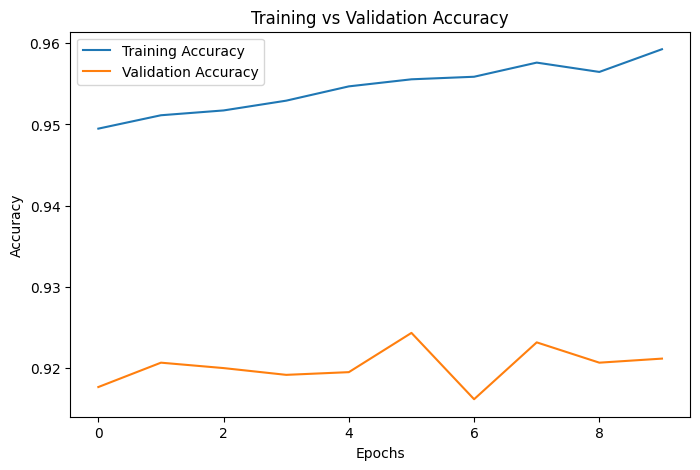

In [15]:
# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

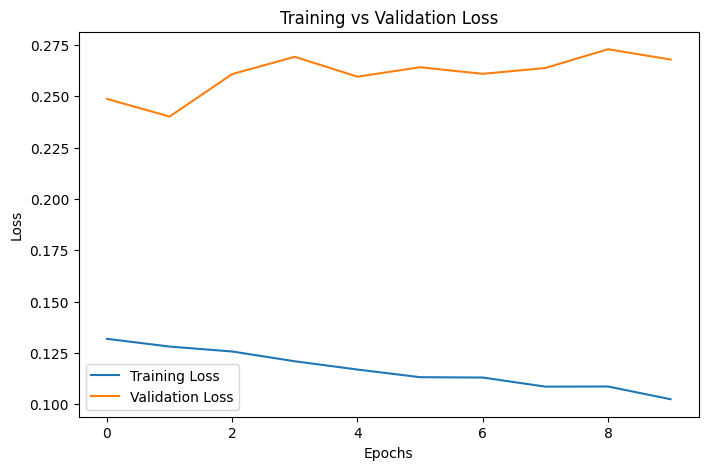

In [16]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

In [17]:
# Evaluate model performance
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("\nTest Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9143 - loss: 0.3116

Test Accuracy: 0.9143000245094299
Test Loss: 0.3116280138492584


In [18]:
# Predict classes
predictions = model.predict(x_test)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [19]:
# Print classification report
print(classification_report(true_classes, predicted_classes, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.86      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.83      0.89      0.85      1000
       Dress       0.92      0.92      0.92      1000
        Coat       0.86      0.87      0.87      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.77      0.72      0.74      1000
     Sneaker       0.96      0.97      0.97      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.98      0.97      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



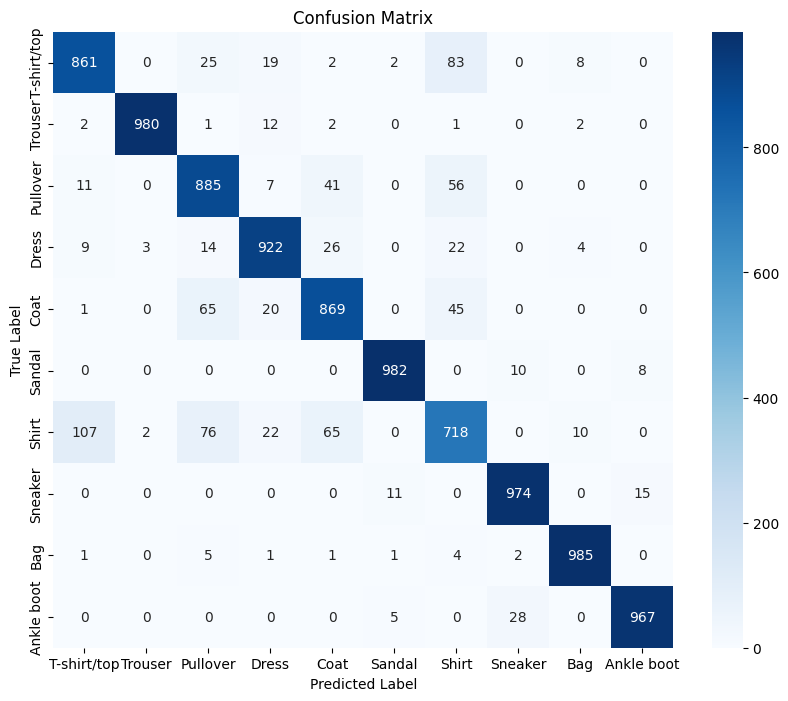

In [20]:
# Generate confusion matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

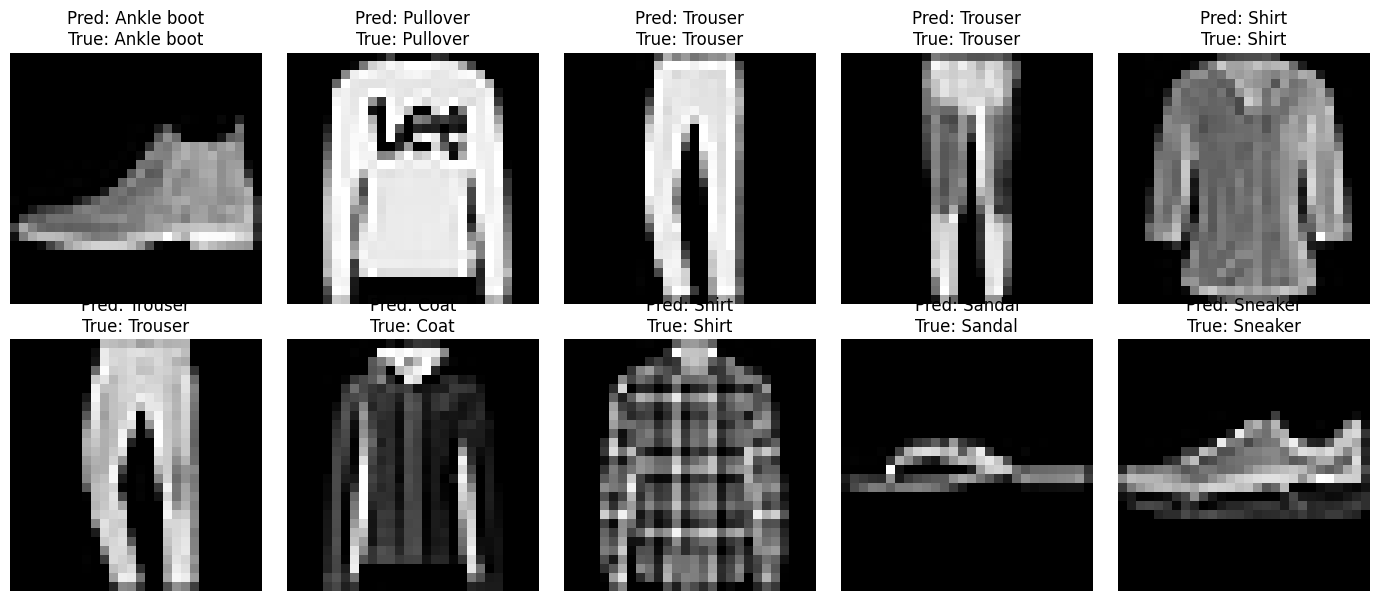

In [21]:
# Show predicted images
plt.figure(figsize=(14, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')

    plt.title(
        f"Pred: {class_names[predicted_classes[i]]}\nTrue: {class_names[true_classes[i]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


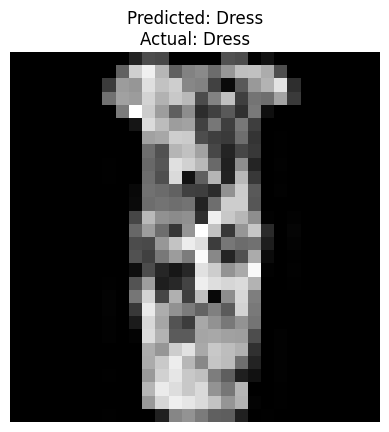

In [22]:
# Select a single image
index = 100

single_image = x_test[index].reshape(1, 28, 28, 1)

# Predict image
prediction = model.predict(single_image)
predicted_label = np.argmax(prediction)
actual_label = true_classes[index]

# Display image
plt.imshow(x_test[index].reshape(28, 28), cmap='gray')

plt.title(
    f"Predicted: {class_names[predicted_label]}\nActual: {class_names[actual_label]}"
)

plt.axis('off')
plt.show()

In [26]:
model.save("fashion_mnist_cnn_model.keras")

In [27]:
from tensorflow.keras.models import load_model

loaded_model = load_model("fashion_mnist_cnn_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [28]:
# Test loaded model
sample_prediction = loaded_model.predict(single_image)

print("Predicted Class:", class_names[np.argmax(sample_prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Predicted Class: Dress
